# Encoding Categorical Data:Solutions to the Exercises

### Companion notebook to *Encoding Categorical Data in Machine Learning*

Worked solutions to the seven exercises in Section 18 of the main notebook.

> **Attempt each exercise yourself before reading its solution.** Several of these produce a result
> that is not the one most people predict, and the value comes from being surprised by your own run
> first. Reading the answer cold turns a genuine insight into a fact to be memorised.

Each solution is laid out the same way:

1. **What is really being tested**:the idea behind the question, which is usually not the same as
   the task it asks you to perform
2. **The solution**: implemented from scratch where the exercise asks for that, and checked
   against the scikit-learn equivalent wherever one exists
3. **What to observe**: how to read the output, and what a complete written answer should say

Where a result contradicts the obvious expectation, the explanation of **why** is the actual answer.
Being able to explain a surprising result is worth far more than remembering a rule.

---

## Contents

| Exercise | Topic | Core idea being tested |
|---|---|---|
| 1 | Count encoding from scratch | Understanding what `value_counts` and `map` really do |
| 2 | Titanic `deck` with heavy missingness | Missingness as information, and feature redundancy |
| 3 | Label vs ordinal encoding | Why a fake ordering distorts a linear coefficient |
| 4 | Binary encoding for 100 categories | The $\lceil \log_2 k \rceil$ column count |
| 5 | Rare category grouping | Trading columns against information |
| 6 | Leave one out vs leaky target encoding | Data leakage measured, not just described |
| 7 | Cyclic encoding of the hour | Circular distance versus linear distance |

Exercises 2 and 3 are controlled experiments rather than from-scratch implementations, so for those
the "solution" is the design of a fair comparison and the reading of its result.

---

## Requirements

```
uv add numpy pandas scikit-learn matplotlib seaborn
```

Same libraries as the main notebook. Nothing extra is needed. Exercise 2 downloads the Titanic
dataset through seaborn, so that section needs an internet connection the first time it runs.

## Reproducing these numbers

Every random seed is fixed, so re-running the notebook end to end gives exactly the output shown.
Small differences may appear on a different scikit-learn version, particularly in the accuracy
tables. The **patterns** being discussed are stable even when the third decimal place is not, so
read the direction and size of each difference rather than the exact digits.


## 0. Setup

We recreate the toy dataset from Section 3 so that this notebook runs on its own,
without needing the main notebook to be executed first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

np.random.seed(42)

import sklearn
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("sklearn :", sklearn.__version__)

numpy   : 2.5.2
pandas  : 3.0.5
sklearn : 1.9.0


In [2]:
# The same toy dataset used in Section 3 of the main notebook
data = {
    'city':      ['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Mumbai', 'Delhi',
                  'Kolkata', 'Chennai', 'Delhi', 'Mumbai', 'Kolkata', 'Delhi'],
    'education': ['Bachelors', 'Masters', 'High School', 'PhD', 'Bachelors', 'Masters',
                  'High School', 'Bachelors', 'PhD', 'Masters', 'Bachelors', 'High School'],
    'gender':    ['Male', 'Female', 'Female', 'Male', 'Male', 'Female',
                  'Male', 'Female', 'Male', 'Female', 'Male', 'Female'],
    'month':     [1, 3, 5, 7, 9, 11, 12, 2, 4, 6, 8, 10],
    'salary':    [50000, 82000, 31000, 120000, 47000, 91000,
                  28000, 55000, 130000, 88000, 42000, 33000],
    'bought':    [0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0]
}

df = pd.DataFrame(data)
df

,city,education,gender,month,salary,bought
0,Delhi,Bachelors,Male,1,50000,0
1,Mumbai,Masters,Female,3,82000,1
2,Delhi,High School,Female,5,31000,0
3,Chennai,PhD,Male,7,120000,1
4,Mumbai,Bachelors,Male,9,47000,0
5,Delhi,Masters,Female,11,91000,1
6,Kolkata,High School,Male,12,28000,0
7,Chennai,Bachelors,Female,2,55000,0
8,Delhi,PhD,Male,4,130000,1
9,Mumbai,Masters,Female,6,88000,1


---
# Exercise 1

> Write a function `count_encode(series)` from scratch that returns the raw counts.
> Verify it against `series.map(series.value_counts())`.

## What is really being tested

The one line answer `series.map(series.value_counts())` is easy to write and easy to use without
understanding. This exercise asks you to prove you know what those two methods do:

* `value_counts()` builds a **Series whose index is the category and whose value is the count**
* `map()` on a Series accepts a dict **or another Series**, and looks each value up **by index**

So `series.map(series.value_counts())` is a table lookup where the lookup table happens to be a
Series. If you can rebuild both halves with a plain Python dictionary, you understand it.

## 1.1 The from scratch version

We deliberately avoid `value_counts` and `collections.Counter`, and count with a dictionary.

In [3]:
def count_encode(series):
    """Replace every value by the number of times it occurs in the series.

    Written without value_counts so that the counting step is visible.
    Returns the encoded Series and the mapping that was learned.
    """
    counts = {}

    # First pass, tally how many times each category appears
    for value in series:
        # NaN is not equal to itself, so it can never be a dictionary key that matches.
        # We map it to a sentinel string and handle it explicitly.
        key = value
        if pd.isna(value):
            key = '__missing__'
        counts[key] = counts.get(key, 0) + 1

    # Second pass, look every row up in the tally we just built
    encoded = []
    for value in series:
        key = '__missing__' if pd.isna(value) else value
        encoded.append(counts[key])

    return pd.Series(encoded, index=series.index, name=str(series.name) + '_count'), counts


encoded, mapping = count_encode(df['city'])

print("Counts learned:", mapping)
print()
pd.DataFrame({'city': df['city'], 'count_encoded': encoded})

Counts learned: {'Delhi': 5, 'Mumbai': 3, 'Chennai': 2, 'Kolkata': 2}



,city,count_encoded
0,Delhi,5
1,Mumbai,3
2,Delhi,5
3,Chennai,2
4,Mumbai,3
5,Delhi,5
6,Kolkata,2
7,Chennai,2
8,Delhi,5
9,Mumbai,3


## 1.2 Verifying against the one line pandas version

Two checks are worth doing. The first compares the values element by element.
The second compares the learned lookup tables themselves, which is the stronger test,
because two different mappings can still agree on the rows that happen to be present.

In [4]:
pandas_version = df['city'].map(df['city'].value_counts())

print("Our version    :", list(encoded.values))
print("pandas version :", list(pandas_version.values))
print()
print("Values identical  :", encoded.equals(pandas_version.rename(encoded.name)))

# Comparing the lookup tables rather than just the encoded rows
pandas_map = df['city'].value_counts().to_dict()
print("Mappings identical:", mapping == pandas_map)

Our version    : [np.int64(5), np.int64(3), np.int64(5), np.int64(2), np.int64(3), np.int64(5), np.int64(2), np.int64(2), np.int64(5), np.int64(3), np.int64(2), np.int64(5)]
pandas version : [np.int64(5), np.int64(3), np.int64(5), np.int64(2), np.int64(3), np.int64(5), np.int64(2), np.int64(2), np.int64(5), np.int64(3), np.int64(2), np.int64(5)]

Values identical  : True
Mappings identical: True


In [5]:
# A stronger test, run both versions on random data of many shapes and sizes
rng = np.random.default_rng(0)

for trial in range(200):
    n_rows = rng.integers(1, 200)
    n_categories = rng.integers(1, 30)
    values = rng.choice(['cat_' + str(i) for i in range(n_categories)], n_rows)
    sample = pd.Series(values, name='x')

    ours, _ = count_encode(sample)
    theirs = sample.map(sample.value_counts())

    assert ours.equals(theirs.rename(ours.name)), f"Mismatch on trial {trial}"

print("All 200 random trials matched")

All 200 random trials matched


## 1.3 Three details the one liner hides

**Detail 1: missing values.** `value_counts()` drops `NaN` by default, so
`series.map(series.value_counts())` returns `NaN` for a missing row rather than a count.
Our version counts them as their own category. Neither is wrong, but you must *choose*.

**Detail 2: count versus frequency.** Counts depend on the size of the dataset. A category seen
50 times in a 100 row training set is common, but 50 times in a million row test set is rare.
Frequency, that is count divided by total rows, is comparable across datasets:

$$ \text{frequency}(c) = \frac{n_c}{N} $$

**Detail 3: unseen categories.** A category that appears only in the test set has no entry in the
mapping. The natural fallback is `0`, because that is literally how many times it was seen during
training.

In [6]:
# Detail 1 in action
with_missing = pd.Series(['A', 'B', np.nan, 'A', np.nan, 'C'], name='x')

ours, ours_map = count_encode(with_missing)
theirs = with_missing.map(with_missing.value_counts())

pd.DataFrame({
    'original': with_missing,
    'our_count_encode': ours,
    'pandas_one_liner': theirs
})

,original,our_count_encode,pandas_one_liner
0,A,2,2.0
1,B,1,1.0
2,NaN,2,NaN
3,A,2,2.0
4,NaN,2,NaN
5,C,1,1.0


In [7]:
class CountEncoder:
    """A fit and transform version, which is what you actually need in a pipeline.

    The counts are learned once from the training data and then reused unchanged,
    so the test set never influences the encoding.
    """

    def __init__(self, normalize=False, unseen_value=0):
        self.normalize = normalize
        self.unseen_value = unseen_value

    def fit(self, series):
        counts = series.value_counts(dropna=False)
        if self.normalize:
            counts = counts / len(series)
        self.mapping_ = counts
        self.n_train_ = len(series)
        return self

    def transform(self, series):
        return series.map(self.mapping_).fillna(self.unseen_value)

    def fit_transform(self, series):
        return self.fit(series).transform(series)


train = pd.Series(['Delhi', 'Mumbai', 'Delhi', 'Chennai', 'Delhi'], name='city')
test = pd.Series(['Delhi', 'Mumbai', 'Bengaluru'], name='city')

encoder = CountEncoder(normalize=False).fit(train)

print("Learned on train only:", encoder.mapping_.to_dict())
print()
pd.DataFrame({
    'test_city': test,
    'count_encoded': encoder.transform(test).values
})

Learned on train only: {'Delhi': 3, 'Mumbai': 1, 'Chennai': 1}



,test_city,count_encoded
0,Delhi,3.0
1,Mumbai,1.0
2,Bengaluru,0.0


`Bengaluru` was never in the training data, so it receives `0`. That is the honest answer:
the model has seen this category zero times. Crucially the encoder did not crash, and the
column count did not change, which is exactly what a deployed model needs.

---
# Exercise 2

> The `deck` column of the Titanic dataset has many missing values. Encode it in two ways,
> first by treating `NaN` as a category called `Unknown`, and second by dropping the column.
> Compare the accuracy.

## What is really being tested

Most students expect "keeping a feature beats throwing it away". The interesting question is
*why* a feature with 77 percent missing values might still help, and *why* it might not.

There are two competing ideas here:

* **Missingness can be informative.** If the cabin was recorded only for expensive tickets, then
  `NaN` is not an absence of data, it is a *signal about ticket class*. Replacing `NaN` with
  `Unknown` lets the model use that signal.
* **Informative missingness is often redundant.** If `NaN` really just means "third class", and
  `pclass` is already a feature, the new column repeats information the model already had.

We will measure both.

## 2.1 Loading the data and looking at the missingness

In [8]:
import seaborn as sns

try:
    titanic = sns.load_dataset('titanic')
    print("Loaded the Titanic dataset from seaborn")
except Exception as err:
    print("Could not download the dataset. Reason:", err)
    raise

print("Shape:", titanic.shape)
print()
print("Missing values per column")
print(titanic.isna().sum().sort_values(ascending=False).head(6))

Loaded the Titanic dataset from seaborn
Shape: (891, 15)

Missing values per column
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
dtype: int64


In [9]:
# deck is stored as a pandas Categorical, which refuses fillna with a new label.
# Converting to plain object first is the simplest fix.
deck = titanic['deck'].astype(object)

print("Data type of the original column :", titanic['deck'].dtype)
print("Missing                          :", deck.isna().sum(), "of", len(deck),
      f"({100 * deck.isna().mean():.1f} percent)")
print()
print(deck.value_counts(dropna=False))

Data type of the original column : category
Missing                          : 688 of 891 (77.2 percent)

deck
NaN    688
C       59
B       47
D       33
E       32
A       15
F       13
G        4
Name: count, dtype: int64


Only 203 of 891 passengers have a recorded deck. Before building any model, we should ask the
obvious question: is `Unknown` different from the rest in a way that matters?

In [10]:
# Survival rate for each deck, with Unknown treated as its own category
deck_filled = deck.fillna('Unknown')

summary = pd.DataFrame({
    'survival_rate': titanic['survived'].groupby(deck_filled).mean(),
    'passengers': deck_filled.value_counts()
}).sort_values('survival_rate')

summary.round(3)

,survival_rate,passengers
deck,,
Unknown,0.299,688
A,0.467,15
G,0.500,4
C,0.593,59
F,0.615,13
B,0.745,47
E,0.750,32
D,0.758,33


This is the whole exercise in one table. Passengers with **no recorded deck survived at about
30 percent**, while every known deck sits between roughly 47 and 76 percent. The `Unknown` label
is not noise, it separates the data sharply.

But before concluding that we have found a valuable feature, we should check where that
separation comes from.

In [11]:
# Is a missing deck simply another way of saying third class?
deck_known = titanic['deck'].notna()

proportion = pd.crosstab(titanic['pclass'], deck_known, normalize='index')
proportion.columns = ['deck_missing', 'deck_recorded']

print("Proportion of passengers with a recorded deck, by class")
print(proportion.round(3))
print()
print("Raw counts")
print(pd.crosstab(titanic['pclass'], deck_known))

Proportion of passengers with a recorded deck, by class
        deck_missing  deck_recorded
pclass                             
1              0.190          0.810
2              0.913          0.087
3              0.976          0.024

Raw counts
deck    False  True 
pclass              
1          41    175
2         168     16
3         479     12


There it is. **81 percent of first class passengers have a recorded deck, against 2.4 percent of
third class.** The `deck` column is very close to being a noisy copy of `pclass`.

So the honest prediction before running the model is: `Unknown` will look informative on its own,
but will add little on top of `pclass`, because `pclass` is already in the feature set.

## 2.2 Building the two versions

We keep everything else identical between the two experiments. Only the presence of the deck
column changes. This is the discipline that makes a comparison meaningful.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

work = titanic[['survived', 'sex', 'embarked', 'pclass', 'age', 'fare']].copy()
work['deck'] = titanic['deck'].astype(object)
work = work.dropna(subset=['embarked'])

work['pclass'] = work['pclass'].astype(str)

# Version A, NaN becomes a category of its own
work['deck_unknown'] = work['deck'].fillna('Unknown')

y = work['survived']
numeric_features = ['age', 'fare']
base_categorical = ['sex', 'embarked', 'pclass']

print("Rows used:", len(work))
print("Categories in the deck column after filling:", work['deck_unknown'].nunique())

Rows used: 889
Categories in the deck column after filling: 8


In [13]:
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])


def evaluate(categorical_features, model, label):
    """Cross validated accuracy for a given set of categorical columns."""
    categorical_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    preprocessor = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features)
    ])
    pipeline = Pipeline([('preprocess', preprocessor), ('model', model)])

    features = categorical_features + numeric_features
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, work[features], y, cv=cv, scoring='accuracy')

    n_columns = preprocessor.fit_transform(work[features], y).shape[1]
    return {'setup': label, 'accuracy': scores.mean(), 'std': scores.std(),
            'encoded_columns': n_columns}


results = []
for model_name, model in [('LogisticRegression', LogisticRegression(max_iter=1000)),
                          ('RandomForest', RandomForestClassifier(n_estimators=300, random_state=42))]:
    for label, features in [('deck dropped', base_categorical),
                            ('deck as Unknown', base_categorical + ['deck_unknown'])]:
        row = evaluate(features, model, label)
        row['model'] = model_name
        results.append(row)

results_df = pd.DataFrame(results)[['model', 'setup', 'encoded_columns', 'accuracy', 'std']]
results_df.round(4)

,model,setup,encoded_columns,accuracy,std
0,LogisticRegression,deck dropped,10,0.7874,0.0068
1,LogisticRegression,deck as Unknown,18,0.7998,0.0144
2,RandomForest,deck dropped,10,0.8189,0.0227
3,RandomForest,deck as Unknown,18,0.8065,0.0266


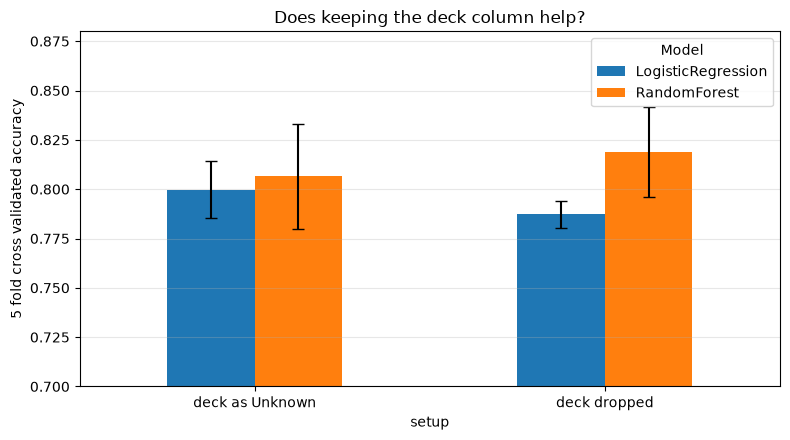

model,LogisticRegression,RandomForest
setup,,
deck as Unknown,0.7998,0.8065
deck dropped,0.7874,0.8189


In [14]:
pivot = results_df.pivot(index='setup', columns='model', values='accuracy')
errors = results_df.pivot(index='setup', columns='model', values='std')

axis = pivot.plot(kind='bar', yerr=errors, capsize=4, figsize=(8, 4.5), rot=0)
plt.ylabel('5 fold cross validated accuracy')
plt.title('Does keeping the deck column help?')
plt.ylim(0.70, 0.88)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

pivot.round(4)

## 2.3 What to observe

Read the error bars before reading the bars.

* For **Logistic Regression**, adding `deck` as `Unknown` gives a small improvement, roughly one
  percentage point.
* For **Random Forest**, adding it makes accuracy slightly *worse*.
* In both cases the change is **comparable to the standard deviation across folds**. That means
  we have not demonstrated a real improvement. We have demonstrated noise.

This is the correct conclusion, and writing it down is the point of the exercise. A one point
difference with a one point standard deviation is not a result.

**Why did such a promising feature do so little?** Because of the crosstab in Section 2.1. The
information in `deck` is almost entirely "was this a first class passenger", and `pclass` was
already in the model. The feature is *informative* but not *additional*.

**Why is the Random Forest slightly hurt?** Adding eight one hot columns that mostly repeat
`pclass` gives the tree more chances to split on noise. With 889 rows, every extra column is a
small overfitting risk.

### The third option the exercise did not mention

There is a tempting third approach: `dropna()` on the deck column, keeping only rows with a
recorded deck. It is worth seeing why that would be a serious mistake.

In [15]:
print("Rows if we drop the deck COLUMN :", len(work))
print("Rows if we drop the deck ROWS   :", work['deck'].notna().sum())
print()
print("Survival rate in the full data      :", round(work['survived'].mean(), 3))
print("Survival rate in the surviving rows :", round(work.loc[work['deck'].notna(), 'survived'].mean(), 3))
print()
print("Class distribution in the full data")
print(work['pclass'].value_counts(normalize=True).round(3).sort_index())
print()
print("Class distribution after dropping rows with a missing deck")
print(work.loc[work['deck'].notna(), 'pclass'].value_counts(normalize=True).round(3).sort_index())

Rows if we drop the deck COLUMN : 889
Rows if we drop the deck ROWS   : 201

Survival rate in the full data      : 0.382
Survival rate in the surviving rows : 0.667

Class distribution in the full data
pclass
1    0.241
2    0.207
3    0.552
Name: proportion, dtype: float64

Class distribution after dropping rows with a missing deck
pclass
1    0.861
2    0.080
3    0.060
Name: proportion, dtype: float64


Dropping the rows throws away 77 percent of the data and leaves a sample that is
overwhelmingly first class, with a survival rate far above the true one. A model trained on that
subset would be measuring a different population altogether. **Dropping a column loses one
feature. Dropping rows can destroy the dataset.**

### Summary for Exercise 2

| Approach | Data kept | Verdict |
|---|---|---|
| `NaN` as `Unknown` | all rows, 8 extra columns | Safe. Small, statistically insignificant gain |
| Drop the column | all rows, fewer columns | Safe. Simpler model, essentially the same accuracy |
| Drop the rows | 23 percent of rows | Unsafe. Biases the sample badly |

When two options tie on accuracy, prefer the simpler one. Here that means dropping the column,
unless `pclass` were unavailable, in which case `Unknown` would suddenly become valuable.

---
# Exercise 3

> Take the `education` column and encode it with (a) label encoding and (b) correct ordinal
> encoding. Train a Logistic Regression on each and explain the difference in the learned
> coefficient.

## What is really being tested

A logistic regression on a single encoded column learns

$$ \log \frac{P(y=1)}{P(y=0)} = w \cdot x_{\text{encoded}} + b $$

so it assumes the log odds move by a **constant amount $w$ for every one unit step** in the
encoded value. Whether that assumption is reasonable depends entirely on whether the encoding
put the categories in a sensible order and at sensible spacings.

Label encoding sorts alphabetically:

```
Bachelors = 0,  High School = 1,  Masters = 2,  PhD = 3
```

Ordinal encoding uses the real order:

```
High School = 0,  Bachelors = 1,  Masters = 2,  PhD = 3
```

Notice that these differ only by a **swap of the first two categories**. That small difference is
enough to matter, as we will see, but only when the data has enough signal to notice.

## 3.1 The two encodings side by side

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

label_map = {category: index for index, category in enumerate(sorted(df['education'].unique()))}
ordinal_map = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}

df['edu_label'] = df['education'].map(label_map)
df['edu_ordinal'] = df['education'].map(ordinal_map)

comparison = (df[['education', 'edu_label', 'edu_ordinal']]
              .drop_duplicates()
              .sort_values('edu_ordinal')
              .reset_index(drop=True))

print("Label encoding (alphabetical):", label_map)
print("Ordinal encoding (true order):", ordinal_map)
print()
comparison

Label encoding (alphabetical): {'Bachelors': 0, 'High School': 1, 'Masters': 2, 'PhD': 3}
Ordinal encoding (true order): {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}



,education,edu_label,edu_ordinal
0,High School,1,0
1,Bachelors,0,1
2,Masters,2,2
3,PhD,3,3


In [17]:
# What does the target actually look like for each education level?
df.groupby('education')['bought'].agg(['mean', 'count']).round(3)

,mean,count
education,,
Bachelors,0.0,4
High School,0.0,3
Masters,1.0,3
PhD,1.0,2


Every High School and Bachelors row has `bought = 0`, and every Masters and PhD row has
`bought = 1`. The relationship is perfectly clean.

## 3.2 Training on each encoding

In [18]:
def fit_and_report(column, name):
    model = LogisticRegression(max_iter=1000)
    model.fit(df[[column]], df['bought'])

    probabilities = model.predict_proba(df[[column]])[:, 1]
    return {
        'encoding': name,
        'coefficient': model.coef_[0][0],
        'intercept': model.intercept_[0],
        'train_accuracy': model.score(df[[column]], df['bought']),
        'log_loss': log_loss(df['bought'], probabilities)
    }


toy_results = pd.DataFrame([
    fit_and_report('edu_label', 'Label (alphabetical)'),
    fit_and_report('edu_ordinal', 'Ordinal (true order)')
])
toy_results.round(4)

,encoding,coefficient,intercept,train_accuracy,log_loss
0,Label (alphabetical),1.6263,-2.5331,1.0,0.2247
1,Ordinal (true order),1.6362,-2.6641,1.0,0.2442


## 3.3 The surprise, and why it happens

The two coefficients are **almost identical**, and both models reach 100 percent training
accuracy. If you expected label encoding to fail here, look again at the mapping.

Alphabetical order gives `Bachelors = 0, High School = 1, Masters = 2, PhD = 3`. The two
categories with `bought = 0` received the codes 0 and 1, and the two with `bought = 1` received
2 and 3. **The swap happened entirely inside a group that shares the same target value**, so the
relationship stayed monotonic and a single threshold at 1.5 still separates the classes perfectly.

The general principle:

> Label encoding does not fail because the order is *wrong*. It fails because the order is
> **not monotonic with respect to the target**. If the scrambling happens to occur between
> categories that behave alike, nothing breaks.

This is exactly why label encoding is often fine for tree models and sometimes fine even for
linear ones. It is also why you cannot rely on it, because you generally do not know in advance
whether the scrambling will land somewhere harmless.

To see the failure, we need a dataset where the two swapped categories genuinely behave
differently.

## 3.4 Making the failure visible

We build a larger dataset where the probability of buying rises steadily with education:

| Education | True $P(\text{buy})$ | Label code | Ordinal code |
|---|---|---|---|
| High School | 0.10 | 1 | 0 |
| Bachelors | 0.30 | 0 | 1 |
| Masters | 0.65 | 2 | 2 |
| PhD | 0.90 | 3 | 3 |

Now the alphabetical order says High School outranks Bachelors, while the data says the opposite.

In [19]:
rng = np.random.default_rng(0)

levels = ['High School', 'Bachelors', 'Masters', 'PhD']
true_probability = {'High School': 0.10, 'Bachelors': 0.30, 'Masters': 0.65, 'PhD': 0.90}

n_samples = 400
education = rng.choice(levels, n_samples)
bought = (rng.random(n_samples) < np.array([true_probability[e] for e in education])).astype(int)

big = pd.DataFrame({'education': education, 'bought': bought})
big['edu_label'] = big['education'].map(label_map)
big['edu_ordinal'] = big['education'].map(ordinal_map)

observed = big.groupby('education')['bought'].agg(['mean', 'count'])
observed['label_code'] = [label_map[i] for i in observed.index]
observed['ordinal_code'] = [ordinal_map[i] for i in observed.index]
observed.sort_values('ordinal_code').round(3)

,mean,count,label_code,ordinal_code
education,,,,
High School,0.111,90,1,0
Bachelors,0.315,89,0,1
Masters,0.571,105,2,2
PhD,0.966,116,3,3


In [20]:
def fit_on_big(column, name):
    model = LogisticRegression(max_iter=1000)
    model.fit(big[[column]], big['bought'])

    codes = pd.DataFrame({column: [label_map[l] if column == 'edu_label' else ordinal_map[l]
                                   for l in levels]})
    predicted = model.predict_proba(codes)[:, 1]

    return model, {
        'encoding': name,
        'coefficient': model.coef_[0][0],
        'intercept': model.intercept_[0],
        'train_accuracy': model.score(big[[column]], big['bought']),
        'log_loss': log_loss(big['bought'], model.predict_proba(big[[column]])[:, 1])
    }, predicted


label_model, label_row, label_predictions = fit_on_big('edu_label', 'Label (alphabetical)')
ordinal_model, ordinal_row, ordinal_predictions = fit_on_big('edu_ordinal', 'Ordinal (true order)')

pd.DataFrame([label_row, ordinal_row]).round(4)

,encoding,coefficient,intercept,train_accuracy,log_loss
0,Label (alphabetical),1.2248,-1.8666,0.7825,0.5180
1,Ordinal (true order),1.5383,-2.3682,0.7825,0.4544


In [21]:
# The predicted probability for each level, next to the truth
prediction_table = pd.DataFrame({
    'true_probability': [true_probability[l] for l in levels],
    'label_encoding_prediction': label_predictions,
    'ordinal_encoding_prediction': ordinal_predictions
}, index=levels)

prediction_table['label_error'] = (prediction_table['label_encoding_prediction']
                                   - prediction_table['true_probability']).abs()
prediction_table['ordinal_error'] = (prediction_table['ordinal_encoding_prediction']
                                     - prediction_table['true_probability']).abs()
prediction_table.round(3)

,true_probability,label_encoding_prediction,ordinal_encoding_prediction,label_error,ordinal_error
High School,0.10,0.345,0.086,0.245,0.014
Bachelors,0.30,0.134,0.304,0.166,0.004
Masters,0.65,0.642,0.670,0.008,0.020
PhD,0.90,0.859,0.904,0.041,0.004


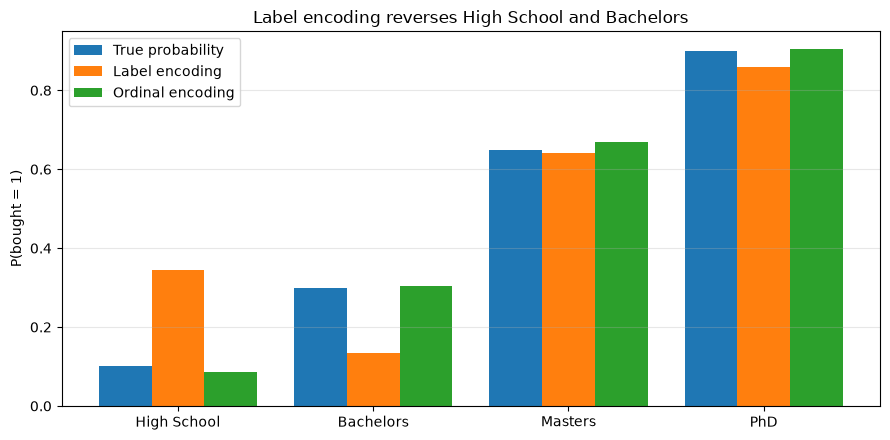

In [22]:
positions = np.arange(len(levels))
width = 0.27

plt.figure(figsize=(9, 4.5))
plt.bar(positions - width, prediction_table['true_probability'], width, label='True probability')
plt.bar(positions, prediction_table['label_encoding_prediction'], width, label='Label encoding')
plt.bar(positions + width, prediction_table['ordinal_encoding_prediction'], width, label='Ordinal encoding')
plt.xticks(positions, levels)
plt.ylabel('P(bought = 1)')
plt.title('Label encoding reverses High School and Bachelors')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3.5 Explaining the difference in the coefficient

Three things changed, and each has a distinct cause.

**1. The coefficient shrank under label encoding (roughly 1.22 against 1.54).**

The model is forced to fit a single slope through four points. With the true order, the four
category log odds increase steadily, so a steep line fits well. With the alphabetical order, the
first two points are swapped, so the sequence goes *down* then up then up. A steep line now
disagrees badly with the first two points, so least badly wrong solution is a **flatter line**.
The fake ordering has *attenuated* the estimated effect of education.

**2. The predicted probabilities for the swapped pair are wrong, and wrong in the worst way.**

Label encoding predicts a **higher** buying probability for High School than for Bachelors,
because it was told High School has the larger code. This is not a small numerical error, it is a
reversed conclusion. If this model were used to target a marketing campaign, it would target
exactly the wrong group.

**3. Accuracy is identical, but log loss is not.**

Both models reach the same accuracy, because accuracy only cares which side of 0.5 the prediction
falls on, and the two damaged predictions happen to stay on the same side. Log loss, which
measures how *confident and correct* the probabilities are, clearly separates them. This is a
general lesson well beyond encoding:

> Accuracy is a blunt metric. A model can be badly miscalibrated and still score well on it.

## 3.6 The reference answer: one hot encoding

When you do not know the correct order, or when the spacing between categories is not uniform,
one hot encoding makes **no ordering assumption at all**. It gives each category its own free
parameter.

In [23]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, drop='first')
encoded_matrix = ohe.fit_transform(big[['education']])

ohe_model = LogisticRegression(max_iter=1000).fit(encoded_matrix, big['bought'])

print("Baseline category (dropped):", ohe.categories_[0][0])
print()
print("Coefficients, each read as the log odds difference from the baseline")
for name, coefficient in zip(ohe.get_feature_names_out(), ohe_model.coef_[0]):
    print(f"  {name:<28} {coefficient:>8.3f}")

print()
summary = pd.DataFrame([
    label_row,
    ordinal_row,
    {'encoding': 'One hot (no assumption)',
     'coefficient': np.nan,
     'intercept': ohe_model.intercept_[0],
     'train_accuracy': ohe_model.score(encoded_matrix, big['bought']),
     'log_loss': log_loss(big['bought'], ohe_model.predict_proba(encoded_matrix)[:, 1])}
])
summary.round(4)

Baseline category (dropped): Bachelors

Coefficients, each read as the log odds difference from the baseline
  education_High School          -1.309
  education_Masters               0.885
  education_PhD                   3.328



,encoding,coefficient,intercept,train_accuracy,log_loss
0,Label (alphabetical),1.2248,-1.8666,0.7825,0.5180
1,Ordinal (true order),1.5383,-2.3682,0.7825,0.4544
2,One hot (no assumption),NaN,-0.6312,0.7825,0.4430


One hot achieves the lowest log loss of the three, because it is the only encoding that can give
each category exactly the probability the data supports. Ordinal encoding comes very close using
a single column instead of three, which is its advantage: when the ordering assumption is
genuinely true, ordinal encoding buys you the same fit with fewer parameters.

### Summary for Exercise 3

| Encoding | Columns | Assumption made | Log loss on the larger dataset |
|---|---|---|---|
| Label (alphabetical) | 1 | Alphabetical order is meaningful | Worst |
| Ordinal (true order) | 1 | The stated order is correct and evenly spaced | Good |
| One hot | k - 1 | Nothing at all | Best |

---
# Exercise 4

> Implement binary encoding for a column with 100 categories and confirm that it produces
> exactly 7 columns.

## What is really being tested

The column count for binary encoding is

$$ \text{columns} = \lceil \log_2 k \rceil $$

For $k = 100$: since $2^6 = 64 < 100 \le 128 = 2^7$, we need $\lceil \log_2 100 \rceil = 7$ bits.
Six bits could only label 64 distinct categories, which is not enough.

There is a subtlety hiding here, and the exercise is designed so you meet it. The main notebook's
implementation starts numbering at **1** rather than 0, so that no category becomes an all zero
row. That changes the formula to $\lceil \log_2 (k+1) \rceil$. For $k = 100$ both formulas give 7,
so the answer is the same either way, but for some values of $k$ they differ. We will find those
values.

## 4.1 The implementation

In [24]:
def binary_encode(series, start_at_one=True):
    """Label encode, then write each integer in binary and split the bits into columns.

    start_at_one shifts every code up by one so that no category is represented
    by an all zero row, which is the convention used in the main notebook.
    """
    categories = sorted(series.unique())
    k = len(categories)

    offset = 1 if start_at_one else 0
    mapping = {category: index + offset for index, category in enumerate(categories)}
    integers = series.map(mapping).values

    # The largest integer we must represent decides how many bits are needed
    largest = k - 1 + offset
    n_bits = max(1, int(np.ceil(np.log2(largest + 1))))

    columns = {}
    for bit in range(n_bits):
        # Shift right by `bit` places and keep the lowest bit
        columns[f"{series.name}_bit{n_bits - 1 - bit}"] = (integers >> (n_bits - 1 - bit)) & 1

    return pd.DataFrame(columns, index=series.index), mapping, n_bits

In [25]:
# Build a column with exactly 100 distinct categories
rng = np.random.default_rng(42)
category_names = ['product_' + str(i).zfill(3) for i in range(100)]

# Every category appears at least once, then extra random rows are added
values = list(category_names) + list(rng.choice(category_names, 400))
column = pd.Series(values, name='product')

print("Rows                :", len(column))
print("Distinct categories :", column.nunique())

encoded, mapping, n_bits = binary_encode(column)

print("Columns produced    :", encoded.shape[1])
print()
assert column.nunique() == 100, "The column must have exactly 100 categories"
assert encoded.shape[1] == 7, f"Expected 7 columns, got {encoded.shape[1]}"
print("Confirmed: 100 categories produce exactly 7 binary columns")

Rows                : 500
Distinct categories : 100
Columns produced    : 7

Confirmed: 100 categories produce exactly 7 binary columns


In [26]:
# Looking at the actual bits for a few categories
inspection = pd.concat([column.rename('product'), encoded], axis=1)
inspection = inspection.drop_duplicates('product').set_index('product')
inspection['integer_code'] = [mapping[p] for p in inspection.index]

pd.concat([inspection.head(5), inspection.tail(5)])

,product_bit6,product_bit5,product_bit4,product_bit3,product_bit2,product_bit1,product_bit0,integer_code
product,,,,,,,,
product_000,0,0,0,0,0,0,1,1
product_001,0,0,0,0,0,1,0,2
product_002,0,0,0,0,0,1,1,3
product_003,0,0,0,0,1,0,0,4
product_004,0,0,0,0,1,0,1,5
product_095,1,1,0,0,0,0,0,96
product_096,1,1,0,0,0,0,1,97
product_097,1,1,0,0,0,1,0,98
product_098,1,1,0,0,0,1,1,99


Read the last row. `product_099` was assigned the integer 100, and 100 in binary is `1100100`,
which is exactly the bit pattern shown. The encoding is doing nothing more mysterious than
writing a number in base 2.

## 4.2 Confirming the count is not a coincidence

An assertion on one value of `k` proves very little. Let us confirm the formula holds across a
range, and check the boundaries where the answer changes.

In [27]:
rows = []
for k in [2, 3, 4, 5, 7, 8, 9, 15, 16, 17, 63, 64, 100, 127, 128, 129, 1000]:
    sample = pd.Series(['c_' + str(i) for i in range(k)], name='c')

    _, _, bits_from_one = binary_encode(sample, start_at_one=True)
    _, _, bits_from_zero = binary_encode(sample, start_at_one=False)

    rows.append({
        'categories_k': k,
        'one_hot_columns': k,
        'ceil_log2_k': int(np.ceil(np.log2(k))),
        'bits_start_at_zero': bits_from_zero,
        'bits_start_at_one': bits_from_one,
        'they_differ': bits_from_zero != bits_from_one
    })

width_table = pd.DataFrame(rows)
width_table

,categories_k,one_hot_columns,ceil_log2_k,bits_start_at_zero,bits_start_at_one,they_differ
0,2,2,1,1,2,True
1,3,3,2,2,2,False
2,4,4,2,2,3,True
3,5,5,3,3,3,False
4,7,7,3,3,3,False
5,8,8,3,3,4,True
6,9,9,4,4,4,False
7,15,15,4,4,4,False
8,16,16,4,4,5,True
9,17,17,5,5,5,False


## 4.3 What to observe

**The formula is confirmed.** `bits_start_at_zero` matches $\lceil \log_2 k \rceil$ in every row.
At $k = 100$ the answer is 7, as required.

**The two conventions disagree at exact powers of two.** Look at $k = 64$ and $k = 128$. Starting
at zero, 128 categories need codes 0 to 127, which fits in 7 bits. Starting at one, they need
codes 1 to 128, and 128 requires an eighth bit. This is a genuine off by one, and it is the kind
of detail that produces a silent shape mismatch between your training and serving code months
later. The lesson is not which convention is right, it is that **you must know which one your
implementation uses.**

**Why avoid the all zero row at all?** With `start_at_one=False`, the first category is encoded as
`0000000`. For a linear model that row contributes nothing to any weighted sum, so the category
becomes indistinguishable from a row of missing values, and it also collides with what
`handle_unknown='ignore'` produces for unseen categories. Starting at one keeps every category
distinguishable at the cost of occasionally needing one extra bit.

## 4.4 Verifying the encoding is lossless

Binary encoding is often described as "lossy" or "collision prone", which is not quite right.
Bits are *shared* between categories, which makes the columns uninterpretable, but the full
pattern is still unique per category. Unlike hashing, binary encoding is fully reversible.

In [28]:
def binary_decode(encoded_frame, mapping):
    """Reconstruct the original categories from the bit columns."""
    inverse = {code: category for category, code in mapping.items()}

    n_bits = encoded_frame.shape[1]
    powers = 2 ** np.arange(n_bits - 1, -1, -1)
    integers = (encoded_frame.values * powers).sum(axis=1)

    return pd.Series([inverse[i] for i in integers], index=encoded_frame.index)


recovered = binary_decode(encoded, mapping)

print("Every row recovered exactly:", recovered.equals(column))
print()
print("Distinct bit patterns :", encoded.drop_duplicates().shape[0])
print("Distinct categories   :", column.nunique())
print("No two categories share a pattern, so the encoding is lossless")

Every row recovered exactly: True

Distinct bit patterns : 100
Distinct categories   : 100
No two categories share a pattern, so the encoding is lossless


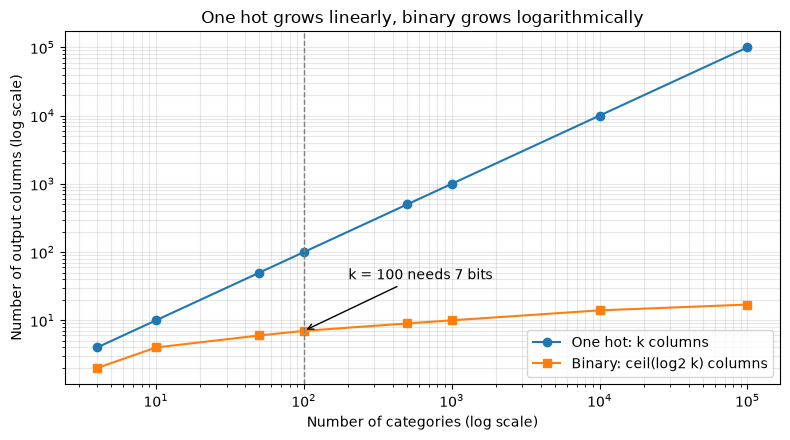

,categories,one_hot,binary,saving_percent
0,4,4,2,50.00
1,10,10,4,60.00
2,50,50,6,88.00
3,100,100,7,93.00
4,500,500,9,98.20
5,1000,1000,10,99.00
6,10000,10000,14,99.86
7,100000,100000,17,99.98


In [29]:
# How the storage saving grows with cardinality
sizes = np.array([4, 10, 50, 100, 500, 1000, 10000, 100000])
binary_columns = np.ceil(np.log2(sizes)).astype(int)

plt.figure(figsize=(8, 4.5))
plt.plot(sizes, sizes, marker='o', label='One hot: k columns')
plt.plot(sizes, binary_columns, marker='s', label='Binary: ceil(log2 k) columns')
plt.axvline(100, linestyle='--', linewidth=1, color='grey')
plt.annotate('k = 100 needs 7 bits', xy=(100, 7), xytext=(200, 40),
             arrowprops={'arrowstyle': '->'})
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of categories (log scale)')
plt.ylabel('Number of output columns (log scale)')
plt.title('One hot grows linearly, binary grows logarithmically')
plt.legend()
plt.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

pd.DataFrame({'categories': sizes, 'one_hot': sizes, 'binary': binary_columns,
              'saving_percent': (100 * (1 - binary_columns / sizes)).round(2)})

---
# Exercise 5

> Build a column with 200 categories where only 5 are common. Apply rare grouping at thresholds
> of 1, 2 and 5 percent, and plot how the number of one hot columns changes.

## What is really being tested

Rare grouping replaces every category below a frequency threshold with a single `Other` label.
The number of one hot columns afterwards is

$$ \text{columns} = \left| \{ c : f_c \ge \tau \} \right| + 1 $$

where $f_c$ is the frequency of category $c$ and $\tau$ is the threshold. The $+1$ is the `Other`
bucket, and it disappears if no category falls below the threshold.

The exercise wants you to see that this count **collapses very sharply** as $\tau$ rises, because
real category distributions are heavily skewed. It is also worth measuring what you *lose*, which
the exercise does not ask for but which is the part that matters in practice.

## 5.1 Building the skewed column

We give the five common categories about 90 percent of the rows between them, and spread the
remaining 10 percent across 195 rare ones. This long tailed shape is what real PIN codes, product
IDs and merchant names look like.

In [30]:
rng = np.random.default_rng(7)

n_common = 5
n_rare = 195
n_rows = 10000

common_names = ['common_' + str(i) for i in range(n_common)]
rare_names = ['rare_' + str(i).zfill(3) for i in range(n_rare)]
all_names = common_names + rare_names

# 90 percent of the probability mass goes to the five common categories
common_weights = np.array([0.30, 0.25, 0.16, 0.11, 0.08])
rare_weights = np.full(n_rare, 0.10 / n_rare)
weights = np.concatenate([common_weights, rare_weights])
weights = weights / weights.sum()

# Every category is seeded once so that the column has exactly 200 distinct values,
# then the remaining rows are drawn according to the skewed weights above
seeded = list(all_names)
sampled = list(rng.choice(all_names, size=n_rows - len(seeded), p=weights))
column = pd.Series(seeded + sampled, name='merchant')

print("Rows                :", len(column))
print("Distinct categories :", column.nunique())
print()
print("The five most frequent categories")
print((100 * column.value_counts(normalize=True).head(5)).round(2).astype(str) + ' %')
print()
print("The five least frequent categories")
print((100 * column.value_counts(normalize=True).tail(5)).round(3).astype(str) + ' %')

Rows                : 10000
Distinct categories : 200

The five most frequent categories
merchant
common_0    29.62 %
common_1    23.96 %
common_2     15.9 %
common_3    10.44 %
common_4     7.97 %
Name: proportion, dtype: str

The five least frequent categories
merchant
rare_114    0.02 %
rare_152    0.02 %
rare_159    0.02 %
rare_194    0.02 %
rare_182    0.01 %
Name: proportion, dtype: str


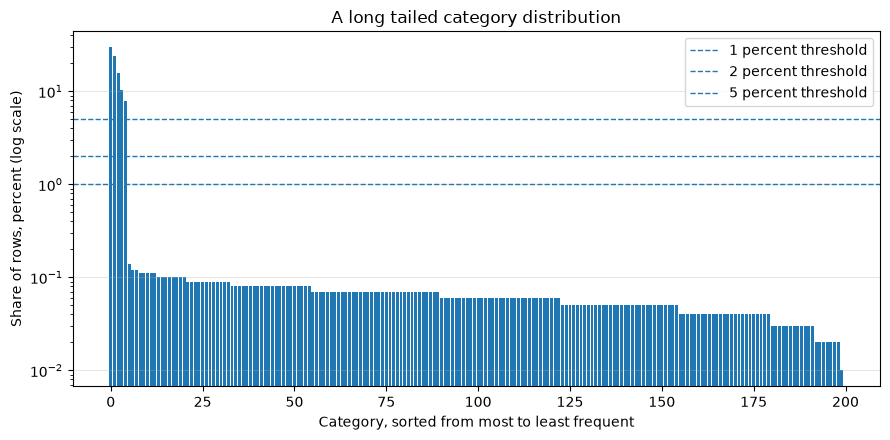

In [31]:
frequencies = column.value_counts(normalize=True)

plt.figure(figsize=(9, 4.5))
plt.bar(range(len(frequencies)), 100 * frequencies.values)
for threshold in [0.01, 0.02, 0.05]:
    plt.axhline(100 * threshold, linestyle='--', linewidth=1,
                label=f'{100 * threshold:g} percent threshold')
plt.yscale('log')
plt.xlabel('Category, sorted from most to least frequent')
plt.ylabel('Share of rows, percent (log scale)')
plt.title('A long tailed category distribution')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The cliff between category 5 and category 6 is enormous, roughly 8 percent against 0.05 percent.
All three thresholds sit inside that gap, which is why, as we are about to see, they will all give
the same answer on this particular column.

## 5.2 Applying the grouping

In [32]:
def group_rare_categories(series, threshold=0.05, other_label='Other'):
    """Replace every category below the frequency threshold with a single label."""
    frequencies = series.value_counts(normalize=True)
    frequent = frequencies[frequencies >= threshold].index
    return series.where(series.isin(frequent), other_label)


def summarise(series, threshold):
    grouped = group_rare_categories(series, threshold)
    one_hot = pd.get_dummies(grouped, dtype=int)

    kept = grouped.nunique() - (1 if 'Other' in set(grouped) else 0)
    return {
        'threshold_percent': 100 * threshold,
        'categories_kept': kept,
        'one_hot_columns': one_hot.shape[1],
        'rows_sent_to_Other': int((grouped == 'Other').sum()),
        'percent_rows_relabelled': 100 * (grouped == 'Other').mean()
    }


required = pd.DataFrame([summarise(column, t) for t in [0.01, 0.02, 0.05]])
print("Without any grouping:", column.nunique(), "one hot columns")
print()
required.round(3)

Without any grouping: 200 one hot columns



,threshold_percent,categories_kept,one_hot_columns,rows_sent_to_Other,percent_rows_relabelled
0,1.0,5,6,1211,12.11
1,2.0,5,6,1211,12.11
2,5.0,5,6,1211,12.11


At all three requested thresholds we go from **200 columns down to 6**, a 97 percent reduction,
while relabelling only about 12 percent of the rows. The three thresholds give identical results
because, as the plot showed, nothing lives between 0.05 percent and 8 percent.

That identical answer is itself informative, but it makes a poor plot. The exercise asks us to
plot how the column count changes, so we sweep a continuous range of thresholds and mark the
three requested values on it.

## 5.3 The plot

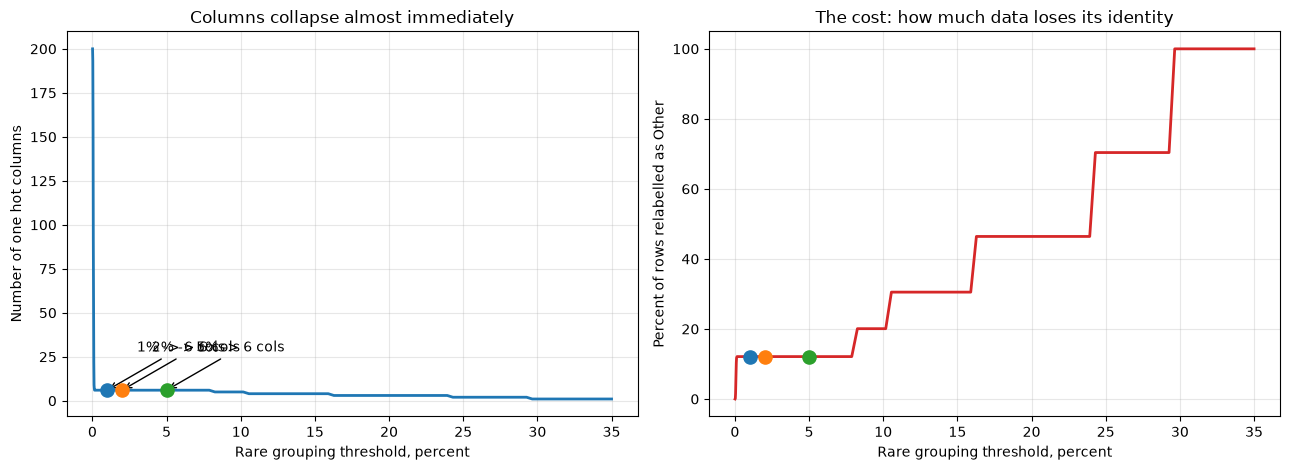

In [33]:
thresholds = np.concatenate([
    np.linspace(0.0001, 0.01, 60),
    np.linspace(0.01, 0.35, 90)
])

sweep = pd.DataFrame([summarise(column, t) for t in thresholds])

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(sweep['threshold_percent'], sweep['one_hot_columns'], linewidth=2)
for threshold in [1, 2, 5]:
    row = required[required['threshold_percent'] == threshold].iloc[0]
    axes[0].scatter([threshold], [row['one_hot_columns']], s=90, zorder=5)
    axes[0].annotate(f"{threshold:g}% -> {int(row['one_hot_columns'])} cols",
                     xy=(threshold, row['one_hot_columns']),
                     xytext=(threshold + 2, row['one_hot_columns'] + 22),
                     arrowprops={'arrowstyle': '->'})
axes[0].set_xlabel('Rare grouping threshold, percent')
axes[0].set_ylabel('Number of one hot columns')
axes[0].set_title('Columns collapse almost immediately')
axes[0].grid(alpha=0.3)

axes[1].plot(sweep['threshold_percent'], sweep['percent_rows_relabelled'],
             linewidth=2, color='tab:red')
for threshold in [1, 2, 5]:
    row = required[required['threshold_percent'] == threshold].iloc[0]
    axes[1].scatter([threshold], [row['percent_rows_relabelled']], s=90, zorder=5)
axes[1].set_xlabel('Rare grouping threshold, percent')
axes[1].set_ylabel('Percent of rows relabelled as Other')
axes[1].set_title('The cost: how much data loses its identity')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# The same information as a table, zoomed into the region where the change happens
zoom = pd.DataFrame([summarise(column, t) for t in
                     [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.09, 0.12, 0.20, 0.30]])
zoom.round(3)

,threshold_percent,categories_kept,one_hot_columns,rows_sent_to_Other,percent_rows_relabelled
0,0.01,200,200,0,0.00
1,0.05,155,156,151,1.51
2,0.10,21,22,1038,10.38
3,0.50,5,6,1211,12.11
4,1.00,5,6,1211,12.11
5,2.00,5,6,1211,12.11
6,5.00,5,6,1211,12.11
7,9.00,4,5,2008,20.08
8,12.00,3,4,3052,30.52
9,20.00,2,3,4642,46.42


## 5.4 What to observe

**The collapse happens far below 1 percent.** At a threshold of 0.1 percent we are already down
from 200 columns to 22, and by 0.5 percent we have reached the final six. The three thresholds the exercise
asked about all sit well past the cliff, which is why they agree. Any threshold between roughly
0.5 and 8 percent would have given the same answer.

**The two curves tell opposite stories, and both matter.** The left plot is the benefit, fewer
columns. The right plot is the cost, more rows losing their identity. Across the whole flat region
the column count stays at six while the relabelled share stays near 12 percent, so nothing is
gained or lost by moving the threshold inside it. Past about 8 percent the left curve barely moves
but the right curve climbs sharply, because you have started deleting genuinely common categories.
That is the point to stop.

**Choose the threshold by looking at the distribution, not by habit.** The common advice "use
1 percent" would work fine here, but only by luck. On a column with categories spread evenly
around 1 percent, that same rule could merge half your data into `Other`. Always plot the sorted
frequencies first.

**A count based threshold is usually safer than a percentage.** "Fewer than 30 occurrences" is
directly tied to how much evidence you have about a category, and it does not change meaning when
the dataset size changes.

In [35]:
# scikit-learn has this built in, via min_frequency
from sklearn.preprocessing import OneHotEncoder

for min_frequency in [0.01, 0.02, 0.05]:
    encoder = OneHotEncoder(min_frequency=min_frequency, sparse_output=False,
                            handle_unknown='infrequent_if_exist')
    encoded = encoder.fit_transform(column.to_frame())
    print(f"min_frequency = {min_frequency:<5} -> {encoded.shape[1]} columns, "
          f"names: {list(encoder.get_feature_names_out())}")

min_frequency = 0.01  -> 6 columns, names: ['merchant_common_0', 'merchant_common_1', 'merchant_common_2', 'merchant_common_3', 'merchant_common_4', 'merchant_infrequent_sklearn']
min_frequency = 0.02  -> 6 columns, names: ['merchant_common_0', 'merchant_common_1', 'merchant_common_2', 'merchant_common_3', 'merchant_common_4', 'merchant_infrequent_sklearn']
min_frequency = 0.05  -> 6 columns, names: ['merchant_common_0', 'merchant_common_1', 'merchant_common_2', 'merchant_common_3', 'merchant_common_4', 'merchant_infrequent_sklearn']


`OneHotEncoder(min_frequency=...)` does the grouping inside the encoder, which is strictly better
than doing it by hand, because the set of frequent categories is learned during `fit` and reused
during `transform`. If you group by hand on the full dataset before splitting, the definition of
"rare" has already been computed using the test set, which is a mild but real form of leakage.

---
# Exercise 6

> Implement leave one out target encoding, then deliberately implement the leaky version.
> Train a Decision Tree on both and compare training accuracy with test accuracy.
> Explain what you see.

## What is really being tested

This is the most important exercise in the set, and the only one where the expected answer is
partly wrong.

The **leaky** encoder uses the row's own target when computing its category mean:

$$ \text{leaky}(x_i) = \frac{1}{n_c} \sum_{j : x_j = x_i} y_j \qquad \text{(includes } y_i \text{)} $$

The **leave one out** encoder removes it:

$$ \text{LOO}(x_i) = \frac{\left(\sum_{j : x_j = x_i} y_j\right) - y_i}{n_c - 1} $$

The standard expectation is that the leaky version overfits and the leave one out version does
not. We are going to measure both, and find that **leave one out also overfits**, for a reason
worth understanding.

## 6.1 The experimental design

To detect leakage cleanly, the best test case is a categorical column that has **no relationship
to the target whatsoever**. If the column is pure noise, then:

* honest test accuracy must be about 50 percent
* any training accuracy above 50 percent is manufactured by the encoder, not learned from data

That makes leakage directly measurable rather than a matter of interpretation.

In [36]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, KFold


def build_dataset(n_rows, n_categories, has_signal, seed):
    """A single high cardinality categorical column and a binary target."""
    rng = np.random.default_rng(seed)
    codes = rng.integers(0, n_categories, n_rows)

    if has_signal:
        # Each category really does have its own buying probability
        probabilities = rng.uniform(0.15, 0.85, n_categories)
    else:
        # Every category is identical, the column carries zero information
        probabilities = np.full(n_categories, 0.5)

    target = (rng.random(n_rows) < probabilities[codes]).astype(int)

    features = pd.Series(['c_' + str(c) for c in codes], name='category')
    return features, pd.Series(target, name='y')

In [37]:
def encode_leaky(series, target):
    """The wrong way. Each row's encoding includes that row's own target."""
    category_mean = target.groupby(series).mean()
    return series.map(category_mean).values, category_mean


def encode_leave_one_out(series, target):
    """Each row's encoding is the mean target over all OTHER rows of the same category."""
    grouped = target.groupby(series)
    category_sum = series.map(grouped.sum())
    category_count = series.map(grouped.count())

    numerator = category_sum - target
    denominator = category_count.sub(1).replace(0, np.nan)

    encoded = (numerator / denominator).fillna(target.mean())

    # At prediction time there is no target to subtract, so the plain mean is used
    return encoded.values, target.groupby(series).mean()


def encode_kfold(series, target, n_splits=5):
    """The recommended way. Each fold is encoded using statistics from the other folds only."""
    encoded = pd.Series(index=series.index, dtype=float)
    splitter = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for train_index, valid_index in splitter.split(series):
        fold_target = target.iloc[train_index]
        fold_series = series.iloc[train_index]

        global_mean = fold_target.mean()
        fold_mean = fold_target.groupby(fold_series).mean()

        encoded.iloc[valid_index] = (series.iloc[valid_index]
                                     .map(fold_mean)
                                     .fillna(global_mean)
                                     .values)

    return encoded.values, target.groupby(series).mean()

In [38]:
def run_experiment(n_categories, has_signal, n_rows=2000, seed=7):
    features, target = build_dataset(n_rows, n_categories, has_signal, seed)

    X_train, X_test, y_train, y_test = train_test_split(
        features, target, test_size=0.3, random_state=0, stratify=target
    )

    rows = []
    encoders = [
        ('Leaky (own row included)', encode_leaky),
        ('Leave one out', encode_leave_one_out),
        ('K-Fold cross fitted', encode_kfold)
    ]

    for name, encoder in encoders:
        train_encoded, mapping = encoder(X_train, y_train)

        # The test set is always transformed with statistics learned on the training set
        test_encoded = X_test.map(mapping).fillna(y_train.mean()).values

        tree = DecisionTreeClassifier(random_state=0)
        tree.fit(train_encoded.reshape(-1, 1), y_train)

        train_accuracy = tree.score(train_encoded.reshape(-1, 1), y_train)
        test_accuracy = tree.score(test_encoded.reshape(-1, 1), y_test)

        rows.append({
            'encoding': name,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'gap': train_accuracy - test_accuracy,
            'corr_with_own_target': np.corrcoef(train_encoded, y_train)[0, 1]
        })

    return pd.DataFrame(rows)

## 6.2 Experiment 1: a column that carries no information at all

In [39]:
noise_results = run_experiment(n_categories=200, has_signal=False)

print("The category column is pure noise, so the honest accuracy is 50 percent")
print()
noise_results.round(4)

The category column is pure noise, so the honest accuracy is 50 percent



,encoding,train_accuracy,test_accuracy,gap,corr_with_own_target
0,Leaky (own row included),0.6657,0.4950,0.1707,0.4088
1,Leave one out,0.6443,0.4983,0.1460,0.0716
2,K-Fold cross fitted,0.5550,0.5183,0.0367,0.0450


Read the `test_accuracy` column first. All three sit at roughly 0.50, which is correct, because the
column genuinely contains nothing. Now read `train_accuracy`:

* The **leaky** encoder produced a model that looks 66 percent accurate on training data
* **Leave one out** produced one that looks 64 percent accurate
* Only the **K-Fold** version reports a training accuracy close to the truth

Both of the first two encoders invented signal out of an empty column. If you had only looked at
training accuracy, you would have reported a working model built on noise.

## 6.3 Experiment 2: a column that does carry real signal

In [40]:
signal_results = run_experiment(n_categories=200, has_signal=True)

print("Each category now has a genuinely different buying probability")
print()
signal_results.round(4)

Each category now has a genuinely different buying probability



,encoding,train_accuracy,test_accuracy,gap,corr_with_own_target
0,Leaky (own row included),0.7264,0.6117,0.1148,0.5407
1,Leave one out,0.6836,0.5767,0.1069,0.3011
2,K-Fold cross fitted,0.6493,0.5950,0.0543,0.3004


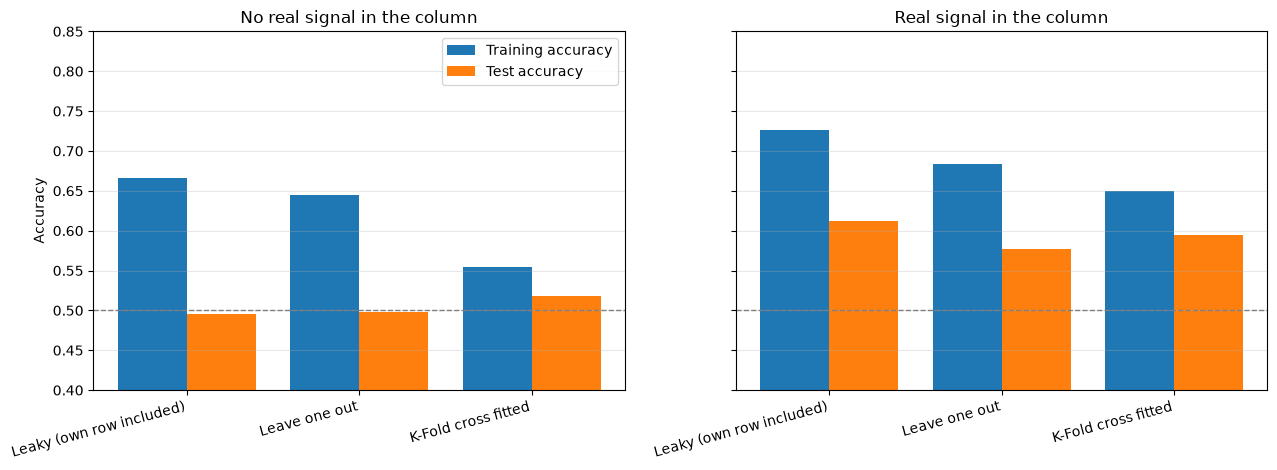

In [41]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)

for axis, results, title in [(axes[0], noise_results, 'No real signal in the column'),
                             (axes[1], signal_results, 'Real signal in the column')]:
    positions = np.arange(len(results))
    axis.bar(positions - 0.2, results['train_accuracy'], 0.4, label='Training accuracy')
    axis.bar(positions + 0.2, results['test_accuracy'], 0.4, label='Test accuracy')
    axis.axhline(0.5, linestyle='--', linewidth=1, color='grey')
    axis.set_xticks(positions)
    axis.set_xticklabels(results['encoding'], rotation=15, ha='right')
    axis.set_title(title)
    axis.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.4, 0.85)
axes[0].legend()
plt.tight_layout()
plt.show()

## 6.4 Explaining what we see

### Why the leaky version overfits

The mechanism is visible in the `corr_with_own_target` column. On a dataset where the true
correlation between the feature and the target is **exactly zero**, the leaky encoding comes out
correlated with the target at around 0.41. That correlation did not come from the data. The
encoder manufactured it.

The arithmetic is easy to see in the extreme case. Suppose a category appears exactly once. Then

$$ \text{leaky}(x_i) = \frac{y_i}{1} = y_i $$

The encoding *is* the answer. With small groups the same effect appears in weaker form: a row with
$y_i = 1$ always pulls its own category mean up, so rows with $y=1$ systematically receive higher
encodings than rows with $y=0$ **within the same category**. A decision tree splits on exactly
that kind of threshold, so it finds the leak immediately.

In [42]:
# Watching the leak directly, with categories of exactly two rows
rng = np.random.default_rng(3)
n = 1000

pairs = pd.Series(['c_' + str(i // 2) for i in range(n)], name='category')
coin_flip = pd.Series(rng.integers(0, 2, n), name='y')

leaky_values = pairs.map(coin_flip.groupby(pairs).mean())

tree = DecisionTreeClassifier(random_state=0).fit(leaky_values.values.reshape(-1, 1), coin_flip)

print("Every category appears exactly twice, and the target is a coin flip")
print()
print("Possible leaky encoding values :", sorted(leaky_values.unique()))
print("Training accuracy of the tree  :", round(tree.score(leaky_values.values.reshape(-1, 1), coin_flip), 4))
print("True achievable accuracy       : 0.5")
print()
print("Mean encoding for rows where y = 0 :", round(leaky_values[coin_flip == 0].mean(), 4))
print("Mean encoding for rows where y = 1 :", round(leaky_values[coin_flip == 1].mean(), 4))
print("These should be equal if there were no leak")

Every category appears exactly twice, and the target is a coin flip

Possible leaky encoding values : [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
Training accuracy of the tree  : 0.751
True achievable accuracy       : 0.5

Mean encoding for rows where y = 0 : 0.2446
Mean encoding for rows where y = 1 : 0.7464
These should be equal if there were no leak


An encoding value of `1.0` means both rows in that pair had `y = 1`, so predicting 1 is always
correct there. The tree scores well above 50 percent on a coin flip, purely from the encoder.

### Why leave one out *also* overfits

This is the part that surprises people, and it is the real lesson of the exercise. Leave one out
removes the direct correlation with $y_i$, which the diagnostic column confirms: the correlation
drops close to zero. Yet the train and test gap remains large. Two things are going on.

**1. Training and test rows are encoded by different formulas.** A training row is encoded with
$n_c - 1$ observations, a test row with all $n_c$. The two sets of numbers therefore have
different means and, more importantly, different spreads. A decision tree learns *thresholds*,
and a threshold tuned to the training distribution does not sit in the right place on the test
distribution. This is a distribution shift the model has no way to know about.

**2. Small groups leak in reverse.** Consider a category with two rows, one with $y=0$ and one with
$y=1$. The row with $y=0$ receives an encoding of 1, and the row with $y=1$ receives 0. The
relationship has been *inverted*, but it is still perfectly predictive on the training set. A tree
is entirely happy to learn "high encoding means class 0" and will be exactly wrong at test time.

Leave one out removes the most obvious leak while leaving a subtler one. It is better than the
naive version and worse than cross fitting.

### Why K-Fold cross fitting works

Every training row is encoded using statistics computed on folds that **do not contain it**, so
the encoding a training row receives is generated the same way as the encoding a genuinely unseen
row would receive. The number a row sees during training is an honest out of sample estimate. The
result is the small gap in the table and, in the signal experiment, competitive test accuracy.

The diagnostic that matters:

> If your training accuracy is far above your test accuracy **and** you used the target to build a
> feature, suspect the encoder before you suspect the model.

## 6.5 The library version

Since version 1.3, scikit-learn's `TargetEncoder` performs cross fitting automatically inside
`fit_transform`, and uses plain category means inside `transform`. That asymmetry is deliberate and
is exactly the behaviour we implemented by hand.

In [43]:
from sklearn.preprocessing import TargetEncoder

features, target = build_dataset(2000, 200, has_signal=False, seed=7)
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.3, random_state=0, stratify=target
)

encoder = TargetEncoder(smooth='auto', random_state=42)

# fit_transform cross fits internally, transform does not, which is why they differ
train_encoded = encoder.fit_transform(X_train.to_frame(), y_train)
train_encoded_wrong = encoder.transform(X_train.to_frame())

print("Mean absolute difference between fit_transform and transform on the SAME rows:",
      round(np.abs(train_encoded - train_encoded_wrong).mean(), 4))
print()
print("They differ because fit_transform is the leakage safe path.")
print("Calling fit(...) then transform(...) on your training data reintroduces the leak.")
print()

tree = DecisionTreeClassifier(random_state=0).fit(train_encoded, y_train)
print("Correct path,  train accuracy:", round(tree.score(train_encoded, y_train), 4))
print("Correct path,  test accuracy :", round(tree.score(encoder.transform(X_test.to_frame()), y_test), 4))

tree_wrong = DecisionTreeClassifier(random_state=0).fit(train_encoded_wrong, y_train)
print("Leaky path,    train accuracy:", round(tree_wrong.score(train_encoded_wrong, y_train), 4))
print("Leaky path,    test accuracy :", round(tree_wrong.score(encoder.transform(X_test.to_frame()), y_test), 4))

Mean absolute difference between fit_transform and transform on the SAME rows: 0.1027

They differ because fit_transform is the leakage safe path.
Calling fit(...) then transform(...) on your training data reintroduces the leak.

Correct path,  train accuracy: 0.5957
Correct path,  test accuracy : 0.5133
Leaky path,    train accuracy: 0.6657
Leaky path,    test accuracy : 0.495


c:\Users\Tavneet\Documents\ml_lab_practicals_csp_dc_305\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


### Summary for Exercise 6

| Encoder | Uses own target | Train and test gap | Verdict |
|---|---|---|---|
| Leaky | Yes, directly | Large | Never use |
| Leave one out | No, but the formula differs at test time | Still large | Better, still unsafe |
| K-Fold cross fitted | No | Small | The correct default |

And the practical rule: **use `TargetEncoder` inside a `Pipeline`, and let `cross_val_score` call
`fit_transform` for you.** Doing it by hand is how the leak gets back in.

---
# Exercise 7

> Encode the hour of the day, 0 to 23, using both plain integers and cyclic encoding.
> Compute the distance between hour 23 and hour 0 in both schemes.

## What is really being tested

Hour 23 and hour 0 are one hour apart. As plain integers they are 23 apart, the maximum possible
distance. Every distance based model, KNN, K-Means, SVM with an RBF kernel, and every linear model
will treat 11pm and midnight as the two most dissimilar times of day, which is the opposite of the
truth.

Cyclic encoding maps the hour onto a circle:

$$ h_{\sin} = \sin\left(\frac{2\pi h}{24}\right), \qquad h_{\cos} = \cos\left(\frac{2\pi h}{24}\right) $$

Every hour becomes a point on the unit circle, and the straight line distance between two points
whose angles differ by $\theta$ is the chord length

$$ d = 2 \left| \sin\left(\frac{\theta}{2}\right) \right| = 2 \left| \sin\left(\frac{\pi \Delta}{24}\right) \right| $$

where $\Delta$ is the difference in hours. This has a useful property: it depends only on
$\Delta \bmod 24$, so 23 and 0 come out at the same distance as 0 and 1.

## 7.1 The two encodings

In [44]:
def cyclic_encode(values, period):
    """Map a cyclic integer feature onto a point on the unit circle."""
    radians = 2 * np.pi * np.asarray(values) / period
    return np.sin(radians), np.cos(radians)


hours = np.arange(24)
hour_sin, hour_cos = cyclic_encode(hours, period=24)

encoding_table = pd.DataFrame({
    'hour': hours,
    'plain_integer': hours,
    'hour_sin': hour_sin.round(4),
    'hour_cos': hour_cos.round(4)
})

pd.concat([encoding_table.head(4), encoding_table.tail(4)])

,hour,plain_integer,hour_sin,hour_cos
0,0,0,0.0000,1.0000
1,1,1,0.2588,0.9659
2,2,2,0.5000,0.8660
3,3,3,0.7071,0.7071
20,20,20,-0.8660,0.5000
21,21,21,-0.7071,0.7071
22,22,22,-0.5000,0.8660
23,23,23,-0.2588,0.9659


## 7.2 The distance the exercise asks for

In [45]:
def integer_distance(a, b):
    return abs(a - b)


def cyclic_distance(a, b, period=24):
    sin_a, cos_a = cyclic_encode(a, period)
    sin_b, cos_b = cyclic_encode(b, period)
    return np.sqrt((sin_a - sin_b) ** 2 + (cos_a - cos_b) ** 2)


pairs = [(23, 0), (0, 1), (11, 12), (23, 22), (0, 12), (6, 18), (3, 9)]

rows = []
for a, b in pairs:
    true_gap = min(abs(a - b), 24 - abs(a - b))
    rows.append({
        'pair': f'{a:>2}h and {b:>2}h',
        'true_hours_apart': true_gap,
        'integer_distance': integer_distance(a, b),
        'cyclic_distance': round(cyclic_distance(a, b), 4)
    })

pd.DataFrame(rows)

,pair,true_hours_apart,integer_distance,cyclic_distance
0,23h and 0h,1,23,0.2611
1,0h and 1h,1,1,0.2611
2,11h and 12h,1,1,0.2611
3,23h and 22h,1,1,0.2611
4,0h and 12h,12,12,2.0000
5,6h and 18h,12,12,2.0000
6,3h and 9h,6,6,1.4142


In [46]:
print("The answer to the exercise")
print()
print("  Distance between hour 23 and hour 0")
print("    plain integer encoding :", integer_distance(23, 0))
print("    cyclic encoding        :", round(cyclic_distance(23, 0), 4))
print()
print("  For comparison, hour 0 and hour 1, which are also one hour apart")
print("    plain integer encoding :", integer_distance(0, 1))
print("    cyclic encoding        :", round(cyclic_distance(0, 1), 4))
print()
print("  Cyclic encoding gives the same distance for both pairs, integer encoding does not.")
print()
print("  Checking against the closed form 2 * sin(pi * delta / 24):")
print("    formula :", round(2 * np.sin(np.pi * 1 / 24), 4))
print("    measured:", round(cyclic_distance(23, 0), 4))

The answer to the exercise

  Distance between hour 23 and hour 0
    plain integer encoding : 23
    cyclic encoding        : 0.2611

  For comparison, hour 0 and hour 1, which are also one hour apart
    plain integer encoding : 1
    cyclic encoding        : 0.2611

  Cyclic encoding gives the same distance for both pairs, integer encoding does not.

  Checking against the closed form 2 * sin(pi * delta / 24):
    formula : 0.2611
    measured: 0.2611


The numbers to remember:

| Pair | Truly apart | Integer distance | Cyclic distance |
|---|---|---|---|
| 23h and 0h | 1 hour | **23** | **0.2611** |
| 0h and 1h | 1 hour | 1 | 0.2611 |
| 0h and 12h | 12 hours | 12 | 2.0 (the maximum) |

The integer encoding gets the first row wrong by a factor of 23. The cyclic encoding gives the
same number for the first two rows, which is exactly what "one hour apart" should mean.

Note also that the cyclic distance **saturates at 2**, the diameter of the circle, reached when
two hours are 12 apart. On a circle there is no such thing as being more than half a cycle away,
because you can always go round the other side.

## 7.3 Seeing the whole picture at once

A single pair of hours proves the point. The full 24 by 24 distance matrix shows the structure.

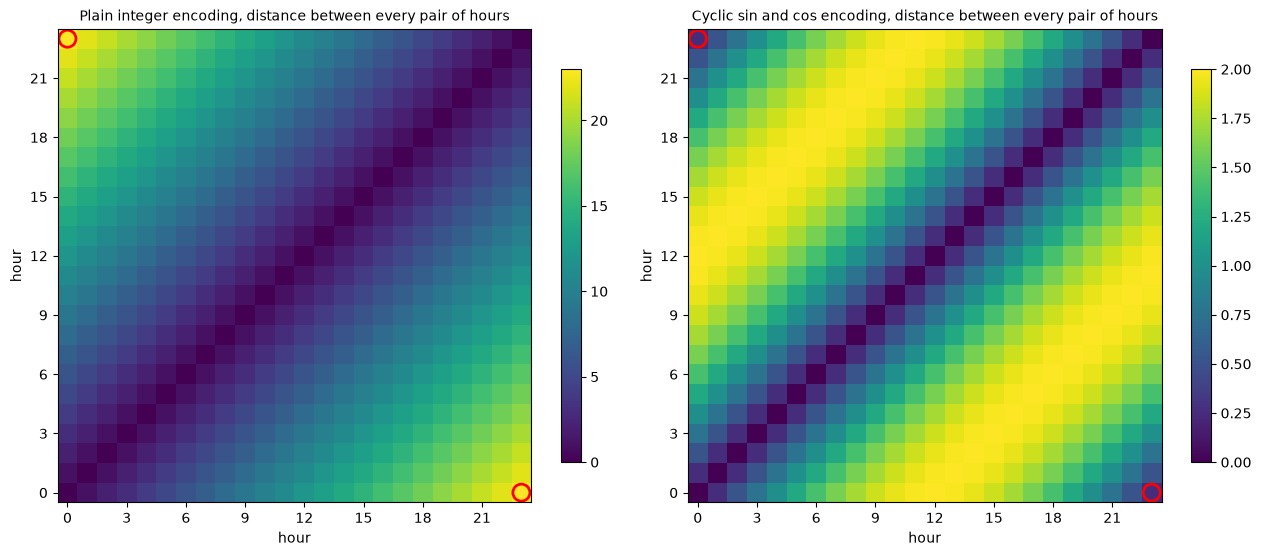

In [47]:
integer_matrix = np.abs(hours[:, None] - hours[None, :])

points = np.column_stack([hour_sin, hour_cos])
differences = points[:, None, :] - points[None, :, :]
cyclic_matrix = np.sqrt((differences ** 2).sum(axis=2))

figure, axes = plt.subplots(1, 2, figsize=(13, 5.4))

for axis, matrix, title in [(axes[0], integer_matrix, 'Plain integer encoding'),
                            (axes[1], cyclic_matrix, 'Cyclic sin and cos encoding')]:
    image = axis.imshow(matrix, cmap='viridis', origin='lower')
    axis.set_xlabel('hour')
    axis.set_ylabel('hour')
    axis.set_title(title + ', distance between every pair of hours', fontsize=10)
    axis.set_xticks(range(0, 24, 3))
    axis.set_yticks(range(0, 24, 3))
    figure.colorbar(image, ax=axis, shrink=0.8)

    # Marking the pair the exercise asks about
    axis.scatter([0], [23], s=150, facecolors='none', edgecolors='red', linewidths=2)
    axis.scatter([23], [0], s=150, facecolors='none', edgecolors='red', linewidths=2)

plt.tight_layout()
plt.show()

The circled corners are the pair 23 and 0. On the left they are the brightest points in the whole
matrix, meaning maximally distant. On the right they are dark, sitting right next to the diagonal
where they belong.

Notice also the structure. The left matrix is a plain V shape, distance rising steadily away from
the diagonal and never coming back. The right matrix has a **second dark diagonal in the corners**,
because the clock wraps around. That extra diagonal is the entire information that plain integer
encoding destroys.

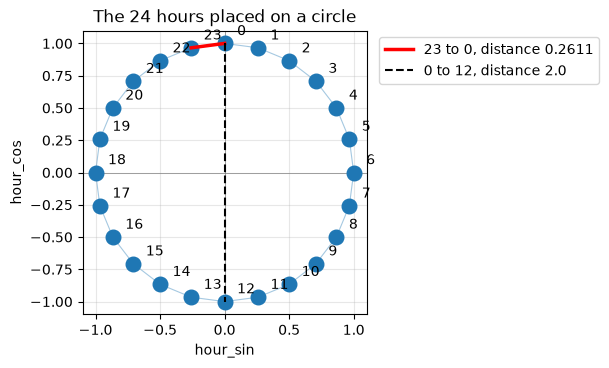

In [48]:
# The 24 hours drawn as points on the circle
plt.figure(figsize=(6.2, 6.2))
plt.plot(np.append(hour_sin, hour_sin[0]), np.append(hour_cos, hour_cos[0]),
         linewidth=0.8, alpha=0.4, zorder=1)
plt.scatter(hour_sin, hour_cos, s=110, zorder=3)

for hour in hours:
    plt.annotate(str(hour), (hour_sin[hour], hour_cos[hour]),
                 textcoords='offset points', xytext=(9, 6))

plt.plot([hour_sin[23], hour_sin[0]], [hour_cos[23], hour_cos[0]],
         color='red', linewidth=2.5, zorder=4,
         label=f'23 to 0, distance {cyclic_distance(23, 0):.4f}')
plt.plot([hour_sin[0], hour_sin[12]], [hour_cos[0], hour_cos[12]],
         color='black', linewidth=1.5, linestyle='--', zorder=4,
         label=f'0 to 12, distance {cyclic_distance(0, 12):.1f}')

plt.axhline(0, linewidth=0.5, color='grey')
plt.axvline(0, linewidth=0.5, color='grey')
plt.xlabel('hour_sin')
plt.ylabel('hour_cos')
plt.title('The 24 hours placed on a circle')
plt.gca().set_aspect('equal')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7.4 Two warnings

**Warning 1: you need both columns.** A single sine column is ambiguous, because
$\sin$ takes the same value at two different hours. Hour 3 and hour 9 both give
$\sin \approx 0.707$. The cosine column is what tells them apart. Dropping one column silently
merges pairs of hours.

In [49]:
ambiguous = pd.DataFrame({
    'hour': [3, 9, 4, 8],
    'hour_sin': hour_sin[[3, 9, 4, 8]].round(4),
    'hour_cos': hour_cos[[3, 9, 4, 8]].round(4)
})

print(ambiguous.to_string(index=False))
print()
print("Hours 3 and 9 share a sine value, and hours 4 and 8 share one too.")
print("Only the cosine column separates them, which is why cyclic encoding needs two columns.")

 hour  hour_sin  hour_cos
    3    0.7071    0.7071
    9    0.7071   -0.7071
    4    0.8660    0.5000
    8    0.8660   -0.5000

Hours 3 and 9 share a sine value, and hours 4 and 8 share one too.
Only the cosine column separates them, which is why cyclic encoding needs two columns.


**Warning 2: cyclic encoding does not help a tree.** A decision tree splits one column at a time
with rules like `hour <= 6.5`. It never computes a distance, so the wrap around problem does not
affect it in the same way. A tree can already isolate `hour >= 22 or hour <= 2` using two splits.
Cyclic encoding is aimed at models that measure distances or fit linear weights.

Let us verify that claim rather than assert it, on a task where night hours behave differently from
day hours.

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

rng = np.random.default_rng(11)
n = 3000

hour_column = rng.integers(0, 24, n)

# Night, defined as 22, 23, 0, 1, 2, 3, has a much higher event rate.
# This group straddles the wrap around point, which is exactly the hard case.
is_night = (hour_column >= 22) | (hour_column <= 3)
event = (rng.random(n) < np.where(is_night, 0.75, 0.25)).astype(int)

integer_features = hour_column.reshape(-1, 1)
sin_values, cos_values = cyclic_encode(hour_column, 24)
cyclic_features = np.column_stack([sin_values, cos_values])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

comparison = []
for model_name, model in [('KNN, 600 neighbours', KNeighborsClassifier(n_neighbors=600)),
                          ('Logistic Regression', LogisticRegression(max_iter=1000)),
                          ('Decision Tree', DecisionTreeClassifier(max_depth=4, random_state=0))]:
    comparison.append({
        'model': model_name,
        'plain_integer': cross_val_score(model, integer_features, event, cv=cv).mean(),
        'cyclic': cross_val_score(model, cyclic_features, event, cv=cv).mean()
    })

comparison_df = pd.DataFrame(comparison)
comparison_df['improvement'] = comparison_df['cyclic'] - comparison_df['plain_integer']
comparison_df.round(4)

,model,plain_integer,cyclic,improvement
0,"KNN, 600 neighbours",0.7237,0.7497,0.0260
1,Logistic Regression,0.6340,0.7253,0.0913
2,Decision Tree,0.7660,0.7660,0.0000


Two of the three results are as predicted, and the third depends on a setting we have not looked
at yet.

* **Logistic Regression improves the most.** With a single integer column it can only fit one
  monotone slope across the day, which simply cannot express "high at both ends, low in the
  middle". The sine and cosine pair can.
* **The Decision Tree does not change at all.** It could already isolate the night hours with two
  splits, `hour <= 3` and `hour >= 22`, so it never needed the circle.
* **KNN improves, but only because we chose 600 neighbours.** That number is doing real work, and
  it is worth understanding why.

## 7.5 Why the KNN result depends on the neighbourhood size

There are 3000 rows spread over only 24 distinct hours, so roughly 125 rows share each hour value
*exactly*. If you ask for the 25 nearest neighbours of a row at hour 23, all 25 are other rows that
are also at hour 23, at distance zero. The neighbourhood never leaves its own hour, so it never
discovers that hour 0 is missing from it, and the wrap around problem is invisible.

The problem only appears once the neighbourhood is wide enough to need rows from adjacent hours.

In [51]:
sweep = []
for n_neighbors in [25, 100, 250, 400, 600, 800]:
    model = KNeighborsClassifier(n_neighbors=n_neighbors)
    integer_score = cross_val_score(model, integer_features, event, cv=cv).mean()
    cyclic_score = cross_val_score(model, cyclic_features, event, cv=cv).mean()
    sweep.append({
        'n_neighbors': n_neighbors,
        'hours_spanned_approx': round(n_neighbors / (n / 24), 2),
        'plain_integer': integer_score,
        'cyclic': cyclic_score,
        'improvement': cyclic_score - integer_score
    })

sweep_df = pd.DataFrame(sweep)
sweep_df.round(4)

,n_neighbors,hours_spanned_approx,plain_integer,cyclic,improvement
0,25,0.2,0.7660,0.7660,0.0000
1,100,0.8,0.7660,0.7660,0.0000
2,250,2.0,0.7610,0.7610,0.0000
3,400,3.2,0.7237,0.7517,0.0280
4,600,4.8,0.7237,0.7497,0.0260
5,800,6.4,0.7027,0.7513,0.0487


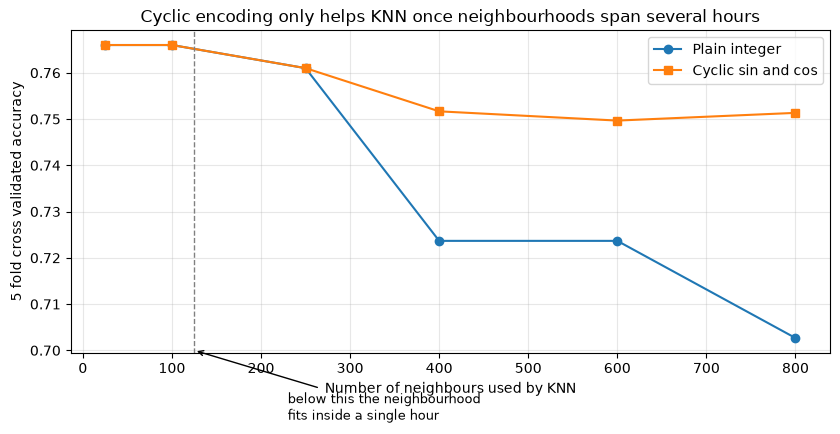

In [52]:
plt.figure(figsize=(8.5, 4.5))
plt.plot(sweep_df['n_neighbors'], sweep_df['plain_integer'], marker='o', label='Plain integer')
plt.plot(sweep_df['n_neighbors'], sweep_df['cyclic'], marker='s', label='Cyclic sin and cos')
plt.axvline(n / 24, linestyle='--', linewidth=1, color='grey')
plt.annotate('below this the neighbourhood\nfits inside a single hour',
             xy=(n / 24, 0.70), xytext=(230, 0.685),
             arrowprops={'arrowstyle': '->'}, fontsize=9)
plt.xlabel('Number of neighbours used by KNN')
plt.ylabel('5 fold cross validated accuracy')
plt.title('Cyclic encoding only helps KNN once neighbourhoods span several hours')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The two lines sit on top of each other for small neighbourhoods and separate as the neighbourhood
grows. Under integer encoding, a wide neighbourhood around hour 23 can only reach backwards into
hours 21 and 22, so it fills up with evening rows and dilutes the night signal. Under cyclic
encoding it reaches hours 0, 1 and 2 as well, which is where the other half of the night lives.

This is a useful thing to have seen. **A negative result in a benchmark often means the setup was
not able to expose the difference, not that the difference does not exist.** If you had run only
the 25 neighbour version, you would have concluded that cyclic encoding is useless for KNN.

The overall theme matches Exercises 2 and 3: the right encoding is not an absolute property of the
column. It depends on which model will consume it, and on how that model is configured.

---
# Closing summary

| Exercise | The expected answer | What the data actually showed |
|---|---|---|
| 1 | Count encoding is a table lookup | True, but `NaN`, unseen categories, and count versus frequency are choices the one liner hides |
| 2 | Keeping an informative column helps | The gain was within one standard deviation, because `deck` mostly repeats `pclass` |
| 3 | Label encoding damages a linear model | Only when the scrambled order is not monotone with the target. On the toy data it was harmless |
| 4 | 100 categories give 7 binary columns | Confirmed, but the count depends on whether codes start at 0 or 1, which differs at powers of two |
| 5 | Higher thresholds mean fewer columns | True, but the collapse finished well below 1 percent, so all three thresholds tied |
| 6 | Leaky encoding overfits, leave one out is safe | Leaky overfits, and leave one out overfits too. Only cross fitting was safe |
| 7 | Cyclic encoding fixes the 23 to 0 distance | Confirmed, 23 becomes 0.2611. But it helps linear and distance based models, not trees, and for KNN only once neighbourhoods span several hours |

## The four ideas worth carrying forward

**1. The encoder and the model are chosen together.** Exercises 2, 3 and 7 all ended with "it
depends on the model". Linear and distance based models are sensitive to the geometry an encoder
imposes. Trees are largely immune to it, and are instead sensitive to the number of columns.

**2. Compare against the standard deviation, not against zero.** Exercise 2 produced a difference
of about one percentage point, with folds varying by about the same amount. That is not a result.
Always run cross validation and always print the spread.

**3. Any encoder that touches the target must be cross fitted.** Exercise 6 showed a model
scoring 66 percent on a column containing nothing at all. Leakage is not a rare edge case, it is
the default outcome of the obvious implementation.

**4. Look at the distribution before choosing a rule.** Exercise 5's three thresholds tied because
of the shape of the data, not because the thresholds were well chosen. Plot the sorted frequencies
first, then pick.

## Suggested extensions

If you finished these quickly, try the following:

1. Repeat Exercise 2 using `TargetEncoder` on `deck` instead of one hot, and check whether the
   smoothing helps the deck categories with only four passengers.
2. In Exercise 3, make the four education levels **unevenly spaced** in probability, for example
   0.10, 0.12, 0.15 and 0.90, and check whether even the correct ordinal encoding is now
   inadequate. This is the case where one hot wins decisively.
3. In Exercise 6, add smoothing to the K-Fold encoder and find the value of `m` that minimises the
   train and test gap.
4. In Exercise 7, encode the day of the week with a period of 7 and check that Sunday and Monday
   come out adjacent.
5. Combine Exercises 4 and 5: group rare categories first, then binary encode what remains, and
   measure the final column count against one hot on the raw column.